# 02. Explainability допустимых признаков — V1

## Главный исследовательский вопрос

**Какие из 47 допустимых признаков стабильно формируют прогноз после полного исключения `Q_B1_norm` и `Q_B2_norm`, и насколько эта картина согласуется между CatBoost, XGBoost и LightGBM?**

### Контролируемый эксперимент

Мы **не улучшаем модель** и не меняем Stage 1 baseline. Фиксируются:

- тот же dataset и SHA-256;
- те же 47 допустимых признаков;
- тот же working/final split;
- те же 3 внешних CV-фолда;
- `seed = 42`;
- те же стартовые параметры CatBoost, XGBoost и LightGBM;
- тот же протокол early stopping: внутренняя validation-часть train-фолда → выбор числа итераций → refit на полном внешнем train-фолде;
- final test остаётся закрытым.

### Что измеряем

1. **Global SHAP** на внешних validation-строках.
2. **Permutation importance** по падению ROC-AUC на тех же validation-строках.
3. Устойчивость рангов между моделями, методами и фолдами.
4. Пересечение с historical importance заказчика.
5. Три локальных SHAP-примера для XGBoost как компактного референса.

### Важное ограничение интерпретации

SHAP и permutation importance показывают **поведение модели и ассоциации**, а не причинное влияние признака на дефолт.

Высокая важность признака после удаления `Q_B1_norm` / `Q_B2_norm` также **не доказывает**, что этот признак содержит тот же сигнал или причинно «заменил» закрытые индексы.


In [2]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import Markdown, display

from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier, early_stopping
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по файлу pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_К_ДАТАСЕТУ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_ОТЧЁТОВ = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПАПКА_ОТЧЁТОВ.mkdir(parents=True, exist_ok=True)

ОЖИДАЕМЫЙ_SHA256 = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"
ОЖИДАЕМЫЙ_SHA_РАБОТА = "80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45"
ОЖИДАЕМЫЙ_SHA_TEST = "35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37"

ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ИДЕНТИФИКАТОР = "INN"
ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ = ["Q_B1_norm", "Q_B2_norm"]

ДОЛЯ_ФИНАЛЬНОГО_TEST = 0.20
ЧИСЛО_ФОЛДОВ = 3
СЛУЧАЙНОЕ_ЗЕРНО = 42
РАННЯЯ_ОСТАНОВКА = 40
ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ = 0.10
ЧИСЛО_ПОТОКОВ = -1

РАЗМЕР_SHAP_ВЫБОРКИ_НА_ФОЛД = 5_000
ПОВТОРОВ_PERMUTATION = 3
ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI = 0.003

ОЖИДАЕМЫЙ_GINI_V2 = {
    "CatBoost": 0.803779690692136,
    "XGBoost": 0.8039898778800276,
    "LightGBM": 0.8033629488861926,
}

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Dataset:", ПУТЬ_К_ДАТАСЕТУ)
print("SHAP:", importlib_metadata.version("shap"))
print("Объясняющая выборка на фолд:", РАЗМЕР_SHAP_ВЫБОРКИ_НА_ФОЛД)
print("Повторов permutation importance:", ПОВТОРОВ_PERMUTATION)

Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Dataset: D:\Projects\komus-credit-risk\data\raw\Data_final.xlsb
SHAP: 0.52.0
Объясняющая выборка на фолд: 5000
Повторов permutation importance: 3


### Анализ настройки

Параметры выше фиксируют именно **Stage 2 V1**. В этом notebook меняется только объект исследования: вместо поиска лучшей модели мы исследуем объяснимость уже принятого baseline.

Чтобы не сделать вычисления чрезмерно дорогими, SHAP и permutation importance считаются на одной и той же стратифицированной подвыборке внешнего validation-фолда — до 5 000 строк на фолд. OOF-качество при этом проверяется на **полном** внешнем validation-фолде.


# 1. Данные и воспроизведение split

## Исследовательский вопрос

Действительно ли Stage 2 использует тот же dataset, те же 47 признаков и те же working/final индексы, что и принятый Stage 1 V2?


In [3]:
if not ПУТЬ_К_ДАТАСЕТУ.exists():
    raise FileNotFoundError(f"Dataset не найден: {ПУТЬ_К_ДАТАСЕТУ}")

фактический_sha256 = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)

if фактический_sha256.lower() != ОЖИДАЕМЫЙ_SHA256.lower():
    raise RuntimeError(
        "SHA-256 dataset не совпал с Stage 1 V2.\n"
        f"Ожидался: {ОЖИДАЕМЫЙ_SHA256}\n"
        f"Получен:  {фактический_sha256}"
    )

начало_чтения = perf_counter()

данные = pd.read_excel(
    ПУТЬ_К_ДАТАСЕТУ,
    engine="pyxlsb",
    sheet_name="Data_final",
).reset_index(drop=True)

время_чтения = perf_counter() - начало_чтения

обязательные = {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ}
отсутствующие = обязательные.difference(данные.columns)
if отсутствующие:
    raise KeyError(f"Отсутствуют обязательные столбцы: {sorted(отсутствующие)}")

данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ] = pd.to_numeric(
    данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ],
    errors="raise",
).astype("int8")

ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in данные.columns
    if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
]

ДОПУСТИМЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ
    if столбец not in ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ
]

for столбец in ДОПУСТИМЫЕ_ПРИЗНАКИ:
    данные[столбец] = pd.to_numeric(
        данные[столбец],
        errors="raise",
    ).astype("float32")

if len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ) != 49:
    raise RuntimeError(
        f"Ожидалось 49 исходных признаков, получено {len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ)}."
    )

if len(ДОПУСТИМЫЕ_ПРИЗНАКИ) != 47:
    raise RuntimeError(
        f"Ожидалось 47 допустимых признаков, получено {len(ДОПУСТИМЫЕ_ПРИЗНАКИ)}."
    )

if set(ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ).intersection(ДОПУСТИМЫЕ_ПРИЗНАКИ):
    raise RuntimeError("Закрытые индексы попали в допустимый feature set.")

if int(данные[ДОПУСТИМЫЕ_ПРИЗНАКИ].isna().sum().sum()) != 0:
    raise RuntimeError("В допустимых признаках появились пропуски.")

if int(данные[ИДЕНТИФИКАТОР].duplicated().sum()) != 0:
    raise RuntimeError("В dataset появились дубликаты INN.")

X_все = данные[ДОПУСТИМЫЕ_ПРИЗНАКИ]
y_все = данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]

индексы = np.arange(len(данные))
индексы_работа, индексы_test = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОГО_TEST,
    stratify=y_все,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

SHA_ИНДЕКСОВ_РАБОТА = хэш_массива(индексы_работа)
SHA_ИНДЕКСОВ_TEST = хэш_массива(индексы_test)

if SHA_ИНДЕКСОВ_РАБОТА != ОЖИДАЕМЫЙ_SHA_РАБОТА:
    raise RuntimeError("Working split не совпал со Stage 1 V2.")

if SHA_ИНДЕКСОВ_TEST != ОЖИДАЕМЫЙ_SHA_TEST:
    raise RuntimeError("Final test split не совпал со Stage 1 V2.")

# Final test намеренно не материализуется в X_test / y_test.
X_работа = X_все.iloc[индексы_работа].reset_index(drop=True)
y_работа = y_все.iloc[индексы_работа].reset_index(drop=True)

КРОСС_ВАЛИДАЦИЯ = StratifiedKFold(
    n_splits=ЧИСЛО_ФОЛДОВ,
    shuffle=True,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

ФОЛДЫ = list(КРОСС_ВАЛИДАЦИЯ.split(X_работа, y_работа))

ПАСПОРТ = pd.DataFrame([
    ("SHA-256 dataset", фактический_sha256),
    ("Строк dataset", len(данные)),
    ("Допустимых признаков", len(ДОПУСТИМЫЕ_ПРИЗНАКИ)),
    ("Исключено", ", ".join(ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ)),
    ("Рабочих строк", len(индексы_работа)),
    ("Final test строк", len(индексы_test)),
    ("SHA working split", SHA_ИНДЕКСОВ_РАБОТА),
    ("SHA final test split", SHA_ИНДЕКСОВ_TEST),
    ("Время чтения, сек", round(время_чтения, 3)),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ)
print("Final test зафиксирован и остаётся закрытым.")

,Проверка,Значение
0,SHA-256 dataset,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,Строк dataset,362018
2,Допустимых признаков,47
3,Исключено,"Q_B1_norm, Q_B2_norm"
4,Рабочих строк,289614
5,Final test строк,72404
6,SHA working split,80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d...
7,SHA final test split,35ec963fe82918841f4a8acb012e8fc878aed66d2c5296...
8,"Время чтения, сек",131.909


Final test зафиксирован и остаётся закрытым.


In [4]:
display(Markdown(f"""
### Анализ полученного результата

- Dataset подтверждён по SHA-256: `{фактический_sha256}`.
- В Stage 2 используются те же **{len(ДОПУСТИМЫЕ_ПРИЗНАКИ)} допустимых признаков**.
- `Q_B1_norm` и `Q_B2_norm` не входят в feature set.
- SHA working split совпал со Stage 1 V2.
- SHA final test split совпал со Stage 1 V2.
- Final test не материализован и не используется.

**Вывод:** explainability строится поверх того же исследовательского контракта, что и принятый baseline.
"""))


### Анализ полученного результата

- Dataset подтверждён по SHA-256: `fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930`.
- В Stage 2 используются те же **47 допустимых признаков**.
- `Q_B1_norm` и `Q_B2_norm` не входят в feature set.
- SHA working split совпал со Stage 1 V2.
- SHA final test split совпал со Stage 1 V2.
- Final test не материализован и не используется.

**Вывод:** explainability строится поверх того же исследовательского контракта, что и принятый baseline.


# 2. Воспроизведение моделей Stage 1 V2

## Исследовательский вопрос

Можем ли мы перед интерпретацией воспроизвести качество Stage 1 V2 тем же протоколом?

Если Gini заметно расходится с зафиксированным baseline, объяснения нельзя считать продолжением того же эксперимента.


In [5]:
ПАРАМЕТРЫ_МОДЕЛЕЙ: dict[str, dict[str, Any]] = {
    "CatBoost": {
        "iterations": 900,
        "learning_rate": 0.06,
        "depth": 7,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "thread_count": ЧИСЛО_ПОТОКОВ,
        "verbose": False,
        "allow_writing_files": False,
    },
    "XGBoost": {
        "n_estimators": 900,
        "learning_rate": 0.06,
        "max_depth": 6,
        "min_child_weight": 3,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "tree_method": "hist",
    },
    "LightGBM": {
        "n_estimators": 900,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "verbosity": -1,
    },
}


def внутреннее_разбиение(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Создаёт внутреннюю validation-часть только внутри внешнего train-фолда."""
    индексы_train = np.arange(len(X_train))
    индексы_fit, индексы_early_stop = train_test_split(
        индексы_train,
        test_size=ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ,
        stratify=y_train,
        random_state=seed,
    )
    return (
        X_train.iloc[индексы_fit],
        X_train.iloc[индексы_early_stop],
        y_train.iloc[индексы_fit],
        y_train.iloc[индексы_early_stop],
    )


def обучить_catboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[CatBoostClassifier, int, float]:
    """Воспроизводит протокол CatBoost из Stage 1 V2."""
    X_fit, X_early_stop, y_fit, y_early_stop = внутреннее_разбиение(
        X_train, y_train, seed
    )
    начало = perf_counter()
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["CatBoost"].copy()

    модель_поиска = CatBoostClassifier(**параметры, random_seed=seed)
    модель_поиска.fit(
        X_fit,
        y_fit,
        eval_set=(X_early_stop, y_early_stop),
        early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
        verbose=False,
    )

    лучшая = модель_поиска.get_best_iteration()
    число_итераций = (
        int(лучшая) + 1
        if лучшая is not None and int(лучшая) >= 0
        else int(параметры["iterations"])
    )

    параметры["iterations"] = число_итераций
    модель = CatBoostClassifier(**параметры, random_seed=seed)
    модель.fit(X_train, y_train)

    return модель, число_итераций, perf_counter() - начало


def обучить_xgboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[XGBClassifier, int, float]:
    """Воспроизводит протокол XGBoost из Stage 1 V2."""
    X_fit, X_early_stop, y_fit, y_early_stop = внутреннее_разбиение(
        X_train, y_train, seed
    )
    начало = perf_counter()
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["XGBoost"].copy()

    модель_поиска = XGBClassifier(
        **параметры,
        random_state=seed,
        early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
    )
    модель_поиска.fit(
        X_fit,
        y_fit,
        eval_set=[(X_early_stop, y_early_stop)],
        verbose=False,
    )

    лучшая = getattr(модель_поиска, "best_iteration", None)
    число_итераций = (
        int(лучшая) + 1
        if лучшая is not None
        else int(параметры["n_estimators"])
    )

    параметры["n_estimators"] = число_итераций
    модель = XGBClassifier(**параметры, random_state=seed)
    модель.fit(X_train, y_train)

    return модель, число_итераций, perf_counter() - начало


def обучить_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[LGBMClassifier, int, float]:
    """Воспроизводит протокол LightGBM из Stage 1 V2."""
    X_fit, X_early_stop, y_fit, y_early_stop = внутреннее_разбиение(
        X_train, y_train, seed
    )
    начало = perf_counter()
    параметры = ПАРАМЕТРЫ_МОДЕЛЕЙ["LightGBM"].copy()

    модель_поиска = LGBMClassifier(**параметры, random_state=seed)
    модель_поиска.fit(
        X_fit,
        y_fit,
        eval_X=X_early_stop,
        eval_y=y_early_stop,
        callbacks=[early_stopping(РАННЯЯ_ОСТАНОВКА, verbose=False)],
    )

    лучшая = getattr(модель_поиска, "best_iteration_", None)
    число_итераций = (
        int(лучшая)
        if лучшая is not None and int(лучшая) > 0
        else int(параметры["n_estimators"])
    )

    параметры["n_estimators"] = число_итераций
    модель = LGBMClassifier(**параметры, random_state=seed)
    модель.fit(X_train, y_train)

    return модель, число_итераций, perf_counter() - начало


def обучить_модель(
    название: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[Any, int, float]:
    """Вызывает строго типизированную ветку обучения нужной модели."""
    if название == "CatBoost":
        return обучить_catboost(X_train, y_train, seed)
    if название == "XGBoost":
        return обучить_xgboost(X_train, y_train, seed)
    if название == "LightGBM":
        return обучить_lightgbm(X_train, y_train, seed)
    raise KeyError(f"Неизвестная модель: {название}")

# 3. SHAP и permutation importance на внешних validation-строках

## Исследовательский вопрос

Какие признаки оказываются важными **на данных, не использованных для обучения соответствующего внешнего фолда**, и насколько вывод совпадает у двух разных методов объяснения?

Для tree-моделей SHAP рассчитывается нативными реализациями:

- CatBoost — `ShapValues`;
- XGBoost — `pred_contribs=True`;
- LightGBM — `pred_contrib=True`.

Последний столбец в этих матрицах — expected value / bias, поэтому в global importance он не входит.

Permutation importance измеряет падение ROC-AUC после перестановки одного признака.


In [6]:
def стратифицированная_подвыборка(
    y: pd.Series,
    размер: int,
    seed: int,
) -> np.ndarray:
    """Возвращает фиксированную стратифицированную подвыборку позиций."""
    индексы = np.arange(len(y))
    if len(y) <= размер:
        return индексы

    выбранные, _ = train_test_split(
        индексы,
        train_size=размер,
        stratify=y,
        random_state=seed,
    )
    return np.sort(выбранные)


def получить_shap(
    название: str,
    модель: Any,
    X: pd.DataFrame,
) -> np.ndarray:
    """Возвращает SHAP-вклады без последнего столбца expected value."""
    if название == "CatBoost":
        pool = Pool(X, feature_names=ДОПУСТИМЫЕ_ПРИЗНАКИ)
        значения = модель.get_feature_importance(
            data=pool,
            type="ShapValues",
            thread_count=ЧИСЛО_ПОТОКОВ,
            verbose=False,
        )
        массив = np.asarray(значения, dtype=np.float64)

    elif название == "XGBoost":
        матрица = xgb.DMatrix(
            X,
            feature_names=ДОПУСТИМЫЕ_ПРИЗНАКИ,
        )
        массив = np.asarray(
            модель.get_booster().predict(
                матрица,
                pred_contribs=True,
                validate_features=True,
            ),
            dtype=np.float64,
        )

    elif название == "LightGBM":
        массив = np.asarray(
            модель.predict(
                X,
                pred_contrib=True,
                validate_features=True,
            ),
            dtype=np.float64,
        )

    else:
        raise KeyError(f"Неизвестная модель: {название}")

    ожидаемая_ширина = len(ДОПУСТИМЫЕ_ПРИЗНАКИ) + 1
    if массив.ndim != 2 or массив.shape[1] != ожидаемая_ширина:
        raise RuntimeError(
            f"{название}: неожиданная форма SHAP {массив.shape}; "
            f"ожидалась (*, {ожидаемая_ширина})."
        )

    return массив[:, :-1]


def получить_локальные_кандидаты_xgboost(
    модель: XGBClassifier,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    вероятности: np.ndarray,
    valid_idx: np.ndarray,
    номер_фолда: int,
) -> list[dict[str, Any]]:
    """Формирует три локальных XGBoost-кандидата из внешнего validation-фолда."""
    y_np = y_valid.to_numpy(dtype=int)
    кандидаты: list[tuple[str, int]] = []

    дефолтные = np.flatnonzero(y_np == 1)
    недефолтные = np.flatnonzero(y_np == 0)

    if len(дефолтные):
        локальный = int(дефолтные[np.argmax(вероятности[дефолтные])])
        кандидаты.append(("Высокий риск, фактический дефолт", локальный))

    if len(недефолтные):
        локальный = int(недефолтные[np.argmin(вероятности[недефолтные])])
        кандидаты.append(("Низкий риск, без дефолта", локальный))

    пограничный = int(np.argmin(np.abs(вероятности - 0.5)))
    кандидаты.append(("Пограничный прогноз", пограничный))

    результат: list[dict[str, Any]] = []

    for сценарий, локальный in кандидаты:
        X_одна = X_valid.iloc[[локальный]]
        shap_одна = получить_shap("XGBoost", модель, X_одна)[0]

        результат.append({
            "Сценарий": сценарий,
            "Фолд": номер_фолда,
            "Индекс рабочей выборки": int(valid_idx[локальный]),
            "Target": int(y_np[локальный]),
            "Вероятность дефолта": float(вероятности[локальный]),
            "Значения признаков": X_одна.iloc[0].to_dict(),
            "SHAP": dict(zip(ДОПУСТИМЫЕ_ПРИЗНАКИ, shap_одна.tolist())),
        })

    return результат

### Перед запуском

Эта ячейка повторно обучит 9 моделей: 3 модели × 3 внешних фолда.

После каждого фолда выводится прогресс. SHAP и permutation importance считаются только после получения модели, прошедшей тот же refit-протокол, что и Stage 1 V2.


In [7]:
начало_эксперимента = perf_counter()

МОДЕЛИ = ["CatBoost", "XGBoost", "LightGBM"]
OOF_ПРОГНОЗЫ: dict[str, np.ndarray] = {
    название: np.full(len(X_работа), np.nan, dtype=np.float64)
    for название in МОДЕЛИ
}

строки_shap: list[dict[str, Any]] = []
строки_permutation: list[dict[str, Any]] = []
строки_обучения: list[dict[str, Any]] = []
локальные_кандидаты: list[dict[str, Any]] = []

ОБЪЯСНИТЕЛЬНЫЕ_ИНДЕКСЫ = {
    номер_фолда: стратифицированная_подвыборка(
        y_работа.iloc[valid_idx].reset_index(drop=True),
        РАЗМЕР_SHAP_ВЫБОРКИ_НА_ФОЛД,
        СЛУЧАЙНОЕ_ЗЕРНО + 100 + номер_фолда,
    )
    for номер_фолда, (_, valid_idx) in enumerate(ФОЛДЫ, start=1)
}

for название in МОДЕЛИ:
    print("\n" + "=" * 72)
    print(f"Модель: {название}")
    print("=" * 72)

    for номер_фолда, (train_idx, valid_idx) in enumerate(ФОЛДЫ, start=1):
        X_train = X_работа.iloc[train_idx]
        y_train = y_работа.iloc[train_idx]
        X_valid = X_работа.iloc[valid_idx]
        y_valid = y_работа.iloc[valid_idx]

        seed = СЛУЧАЙНОЕ_ЗЕРНО + номер_фолда
        модель, число_итераций, время_обучения = обучить_модель(
            название,
            X_train,
            y_train,
            seed,
        )

        вероятности = np.asarray(
            модель.predict_proba(X_valid),
            dtype=np.float64,
        )[:, 1]

        OOF_ПРОГНОЗЫ[название][valid_idx] = вероятности

        roc_auc_фолда = float(roc_auc_score(y_valid, вероятности))
        gini_фолда = float(2 * roc_auc_фолда - 1)

        позиции = ОБЪЯСНИТЕЛЬНЫЕ_ИНДЕКСЫ[номер_фолда]
        X_объяснение = X_valid.iloc[позиции].copy()
        y_объяснение = y_valid.iloc[позиции].copy()

        начало_shap = perf_counter()
        shap_значения = получить_shap(
            название,
            модель,
            X_объяснение,
        )
        время_shap = perf_counter() - начало_shap

        mean_abs_shap = np.mean(np.abs(shap_значения), axis=0)

        for признак, важность in zip(ДОПУСТИМЫЕ_ПРИЗНАКИ, mean_abs_shap):
            строки_shap.append({
                "Модель": название,
                "Фолд": номер_фолда,
                "Признак": признак,
                "Средний |SHAP|": float(важность),
            })

        начало_perm = perf_counter()
        permutation = permutation_importance(
            модель,
            X_объяснение,
            y_объяснение,
            scoring="roc_auc",
            n_repeats=ПОВТОРОВ_PERMUTATION,
            random_state=СЛУЧАЙНОЕ_ЗЕРНО + 1000 + номер_фолда,
            n_jobs=1,
        )
        время_perm = perf_counter() - начало_perm

        for индекс_признака, признак in enumerate(ДОПУСТИМЫЕ_ПРИЗНАКИ):
            строки_permutation.append({
                "Модель": название,
                "Фолд": номер_фолда,
                "Признак": признак,
                "Падение ROC-AUC": float(permutation.importances_mean[индекс_признака]),
                "Std permutation": float(permutation.importances_std[индекс_признака]),
            })

        строки_обучения.append({
            "Модель": название,
            "Фолд": номер_фолда,
            "Gini": gini_фолда,
            "Лучшая итерация": int(число_итераций),
            "Время обучения, сек": float(время_обучения),
            "Время SHAP, сек": float(время_shap),
            "Время permutation, сек": float(время_perm),
            "Строк объяснения": int(len(X_объяснение)),
        })

        if название == "XGBoost":
            локальные_кандидаты.extend(
                получить_локальные_кандидаты_xgboost(
                    модель=модель,
                    X_valid=X_valid,
                    y_valid=y_valid,
                    вероятности=вероятности,
                    valid_idx=valid_idx,
                    номер_фолда=номер_фолда,
                )
            )

        print(
            f"{название} · фолд {номер_фолда}: "
            f"Gini={gini_фолда:.4f}; "
            f"итераций={число_итераций}; "
            f"train={время_обучения:.1f} сек.; "
            f"SHAP={время_shap:.1f} сек.; "
            f"permutation={время_perm:.1f} сек."
        )

for название, oof in OOF_ПРОГНОЗЫ.items():
    if np.isnan(oof).any():
        raise RuntimeError(f"OOF-прогнозы {название} заполнены не полностью.")

ОБЩЕЕ_ВРЕМЯ_ЭКСПЕРИМЕНТА = perf_counter() - начало_эксперимента

ТАБЛИЦА_SHAP_ФОЛДЫ = pd.DataFrame(строки_shap)
ТАБЛИЦА_PERM_ФОЛДЫ = pd.DataFrame(строки_permutation)
ТАБЛИЦА_ОБУЧЕНИЯ = pd.DataFrame(строки_обучения)

print(f"\nОбщее время Stage 2 V1: {ОБЩЕЕ_ВРЕМЯ_ЭКСПЕРИМЕНТА:.1f} сек.")


Модель: CatBoost
CatBoost · фолд 1: Gini=0.7965; итераций=531; train=48.9 сек.; SHAP=1.6 сек.; permutation=1.6 сек.
CatBoost · фолд 2: Gini=0.8051; итераций=607; train=56.6 сек.; SHAP=2.1 сек.; permutation=1.6 сек.
CatBoost · фолд 3: Gini=0.8097; итераций=760; train=73.1 сек.; SHAP=2.7 сек.; permutation=1.6 сек.

Модель: XGBoost
XGBoost · фолд 1: Gini=0.7974; итераций=417; train=16.1 сек.; SHAP=2.0 сек.; permutation=2.4 сек.
XGBoost · фолд 2: Gini=0.8060; итераций=395; train=14.8 сек.; SHAP=1.9 сек.; permutation=2.5 сек.
XGBoost · фолд 3: Gini=0.8088; итераций=434; train=15.7 сек.; SHAP=2.1 сек.; permutation=2.5 сек.

Модель: LightGBM
LightGBM · фолд 1: Gini=0.7974; итераций=639; train=21.9 сек.; SHAP=4.8 сек.; permutation=6.1 сек.
LightGBM · фолд 2: Gini=0.8048; итераций=449; train=17.3 сек.; SHAP=3.3 сек.; permutation=4.4 сек.
LightGBM · фолд 3: Gini=0.8083; итераций=456; train=14.9 сек.; SHAP=3.4 сек.; permutation=4.4 сек.

Общее время Stage 2 V1: 335.1 сек.


In [8]:
строки_качества = []

for название in МОДЕЛИ:
    oof = OOF_ПРОГНОЗЫ[название]
    roc_auc = float(roc_auc_score(y_работа, oof))
    gini = float(2 * roc_auc - 1)
    pr_auc = float(average_precision_score(y_работа, oof))
    отклонение = float(gini - ОЖИДАЕМЫЙ_GINI_V2[название])

    строки_качества.append({
        "Модель": название,
        "ROC-AUC OOF": roc_auc,
        "Gini OOF": gini,
        "PR-AUC OOF": pr_auc,
        "Gini Stage 1 V2": ОЖИДАЕМЫЙ_GINI_V2[название],
        "Отклонение Gini": отклонение,
    })

    if abs(отклонение) > ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI:
        raise RuntimeError(
            f"{название}: Gini отклонился от Stage 1 V2 на {отклонение:.4f}, "
            f"что больше допустимых {ПРЕДЕЛ_ОТКЛОНЕНИЯ_GINI:.4f}."
        )

ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ = pd.DataFrame(строки_качества)
display(
    ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ.style.format({
        "ROC-AUC OOF": "{:.4f}",
        "Gini OOF": "{:.4f}",
        "PR-AUC OOF": "{:.4f}",
        "Gini Stage 1 V2": "{:.4f}",
        "Отклонение Gini": "{:+.4f}",
    })
)

display(Markdown("""
### Вывод по воспроизводимости

Если эта ячейка завершилась без `RuntimeError`, OOF Gini всех трёх моделей находится в заранее заданном допуске относительно Stage 1 V2.

Только после этой проверки интерпретации ниже считаются относящимися к принятому baseline.
"""))

,Модель,ROC-AUC OOF,Gini OOF,PR-AUC OOF,Gini Stage 1 V2,Отклонение Gini
0,CatBoost,0.9019,0.8038,0.6010,0.8038,+0.0000
1,XGBoost,0.9020,0.8040,0.5993,0.8040,+0.0000
2,LightGBM,0.9017,0.8034,0.5978,0.8034,+0.0000



### Вывод по воспроизводимости

Если эта ячейка завершилась без `RuntimeError`, OOF Gini всех трёх моделей находится в заранее заданном допуске относительно Stage 1 V2.

Только после этой проверки интерпретации ниже считаются относящимися к принятому baseline.


# 4. Global importance и согласованность методов

## Исследовательский вопрос

Какие признаки стабильно занимают верхние позиции, если:

- агрегировать объяснения по трём внешним фолдам;
- сравнить SHAP и permutation importance;
- не опираться на одну конкретную модель?


,Признак,Средний ранг,Std ранга,Consensus место
0,Q_D6_norm,1.00,0.00,1
1,Q_A5_norm,3.33,0.52,2
2,Q_B3_norm,3.33,1.51,3
3,Q_C1_norm,3.50,1.64,4
4,G1_norm,5.17,1.94,5
5,Q_D4_norm,6.17,2.40,6
6,D5_norm,7.17,1.33,7
7,A4_norm,8.50,1.22,8
8,C4_norm,9.83,2.79,9
9,Q_A4_norm,10.33,0.52,10


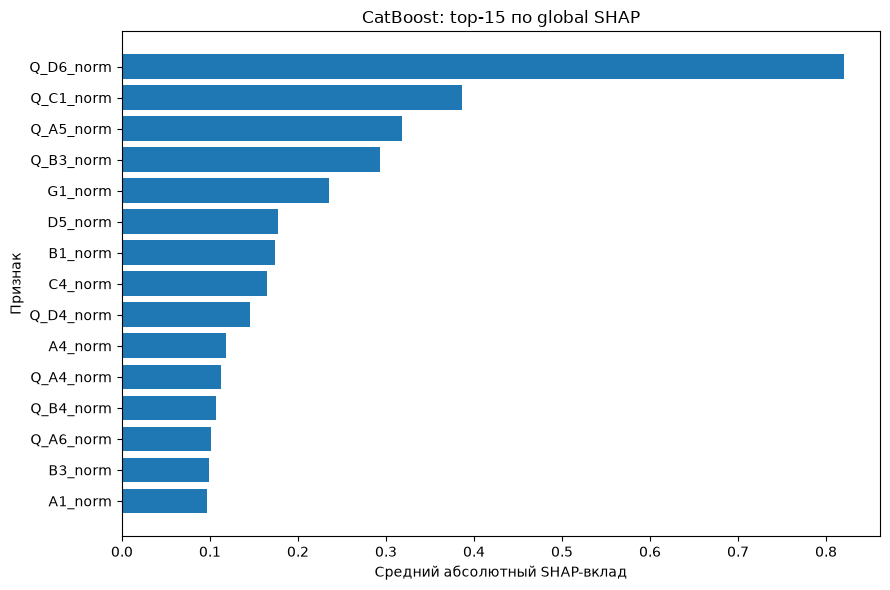

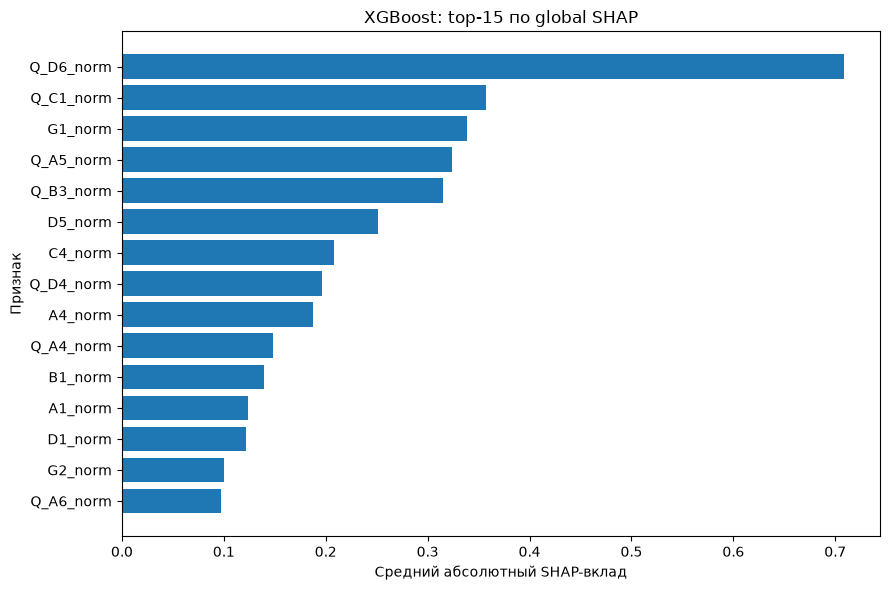

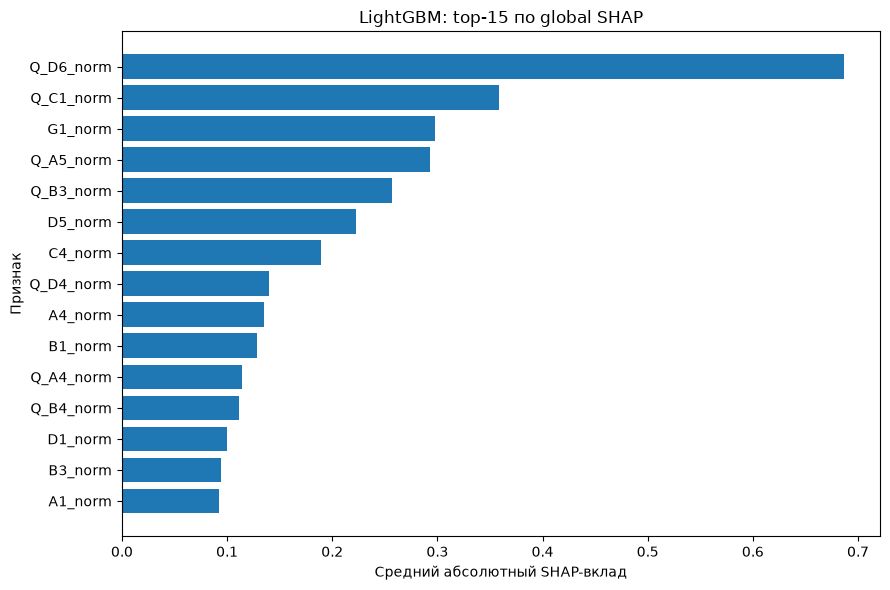

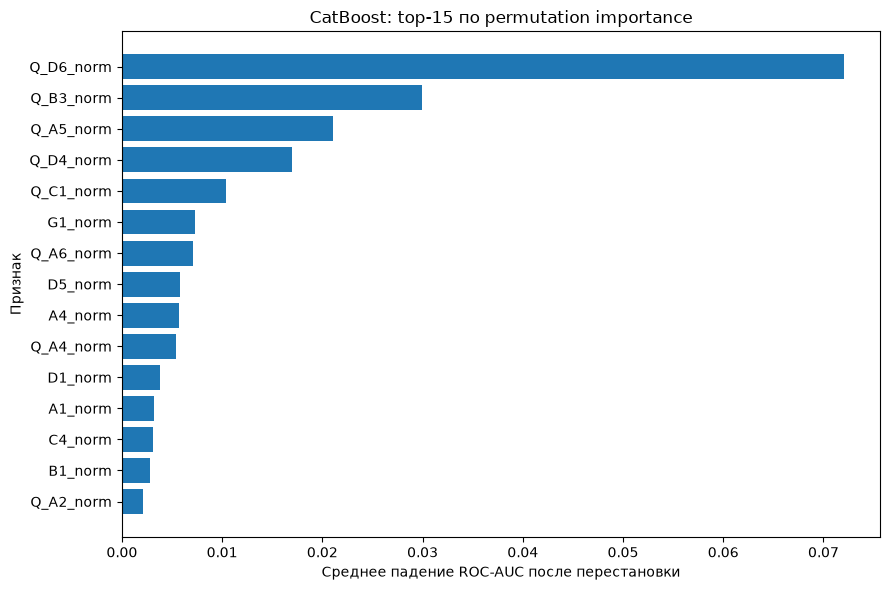

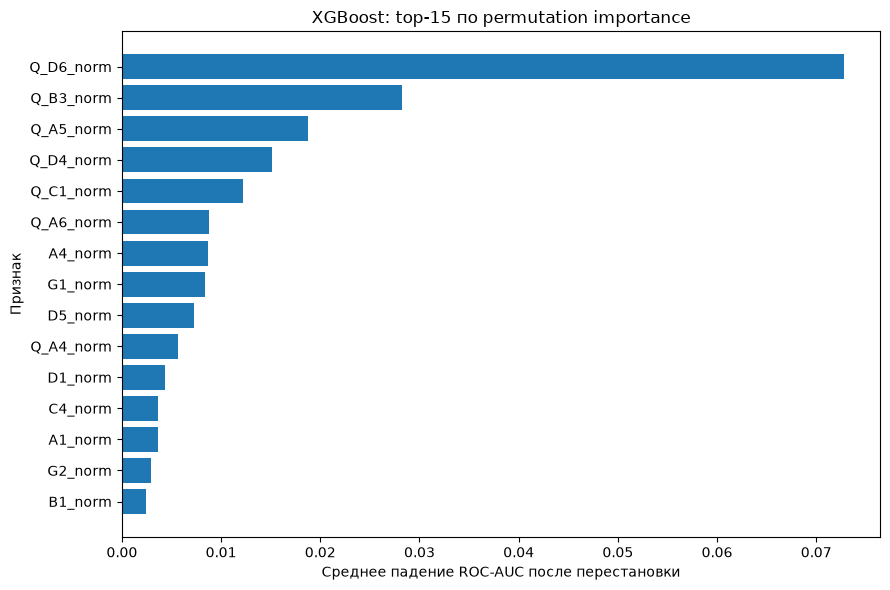

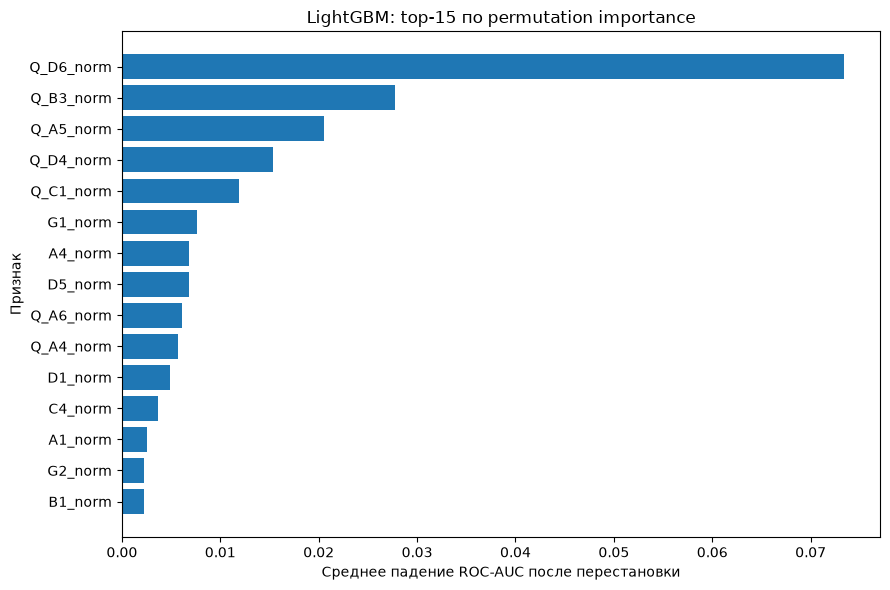

In [9]:
ТАБЛИЦА_SHAP = (
    ТАБЛИЦА_SHAP_ФОЛДЫ
    .groupby(["Модель", "Признак"], as_index=False)
    .agg(
        **{
            "Средний |SHAP|": ("Средний |SHAP|", "mean"),
            "Std |SHAP| по фолдам": ("Средний |SHAP|", "std"),
        }
    )
)

ТАБЛИЦА_PERM = (
    ТАБЛИЦА_PERM_ФОЛДЫ
    .groupby(["Модель", "Признак"], as_index=False)
    .agg(
        **{
            "Падение ROC-AUC": ("Падение ROC-AUC", "mean"),
            "Std падения по фолдам": ("Падение ROC-AUC", "std"),
        }
    )
)

ТАБЛИЦА_SHAP["Ранг SHAP"] = (
    ТАБЛИЦА_SHAP
    .groupby("Модель")["Средний |SHAP|"]
    .rank(method="average", ascending=False)
)

ТАБЛИЦА_PERM["Ранг permutation"] = (
    ТАБЛИЦА_PERM
    .groupby("Модель")["Падение ROC-AUC"]
    .rank(method="average", ascending=False)
)

ранги = (
    ТАБЛИЦА_SHAP[["Модель", "Признак", "Ранг SHAP"]]
    .merge(
        ТАБЛИЦА_PERM[["Модель", "Признак", "Ранг permutation"]],
        on=["Модель", "Признак"],
        how="inner",
        validate="one_to_one",
    )
)

широкие_ранги = ранги.pivot(
    index="Признак",
    columns="Модель",
    values=["Ранг SHAP", "Ранг permutation"],
)

ТАБЛИЦА_CONSENSUS = pd.DataFrame({
    "Признак": широкие_ранги.index,
    "Средний ранг": широкие_ранги.mean(axis=1).to_numpy(),
    "Std ранга": широкие_ранги.std(axis=1, ddof=1).to_numpy(),
}).sort_values(
    ["Средний ранг", "Std ранга"],
    ascending=[True, True],
).reset_index(drop=True)

ТАБЛИЦА_CONSENSUS["Consensus место"] = np.arange(
    1,
    len(ТАБЛИЦА_CONSENSUS) + 1,
)

display(ТАБЛИЦА_CONSENSUS.head(20).style.format({
    "Средний ранг": "{:.2f}",
    "Std ранга": "{:.2f}",
}))

for название in МОДЕЛИ:
    top = (
        ТАБЛИЦА_SHAP
        .query("Модель == @название")
        .sort_values("Средний |SHAP|", ascending=False)
        .head(15)
        .sort_values("Средний |SHAP|", ascending=True)
    )

    plt.figure(figsize=(9, 6))
    plt.barh(top["Признак"], top["Средний |SHAP|"])
    plt.xlabel("Средний абсолютный SHAP-вклад")
    plt.ylabel("Признак")
    plt.title(f"{название}: top-15 по global SHAP")
    plt.tight_layout()
    plt.show()

for название in МОДЕЛИ:
    top = (
        ТАБЛИЦА_PERM
        .query("Модель == @название")
        .sort_values("Падение ROC-AUC", ascending=False)
        .head(15)
        .sort_values("Падение ROC-AUC", ascending=True)
    )

    plt.figure(figsize=(9, 6))
    plt.barh(top["Признак"], top["Падение ROC-AUC"])
    plt.xlabel("Среднее падение ROC-AUC после перестановки")
    plt.ylabel("Признак")
    plt.title(f"{название}: top-15 по permutation importance")
    plt.tight_layout()
    plt.show()

In [10]:
def корреляция_рангов(
    таблица: pd.DataFrame,
    колонка_важности: str,
) -> pd.DataFrame:
    """Строит Spearman-подобную корреляцию через Pearson по рангам."""
    матрица = таблица.pivot(
        index="Признак",
        columns="Модель",
        values=колонка_важности,
    )
    ранги_матрицы = матрица.rank(axis=0, ascending=False)
    return ранги_матрицы.corr(method="pearson")


КОРРЕЛЯЦИЯ_SHAP_МЕЖДУ_МОДЕЛЯМИ = корреляция_рангов(
    ТАБЛИЦА_SHAP,
    "Средний |SHAP|",
)

КОРРЕЛЯЦИЯ_PERM_МЕЖДУ_МОДЕЛЯМИ = корреляция_рангов(
    ТАБЛИЦА_PERM,
    "Падение ROC-AUC",
)

согласие_методов = []

for название in МОДЕЛИ:
    temp = (
        ранги
        .query("Модель == @название")
        [["Ранг SHAP", "Ранг permutation"]]
    )
    корреляция = float(
        temp["Ранг SHAP"].corr(temp["Ранг permutation"], method="pearson")
    )
    согласие_методов.append({
        "Модель": название,
        "Корреляция рангов SHAP ↔ permutation": корреляция,
    })

ТАБЛИЦА_СОГЛАСИЯ_МЕТОДОВ = pd.DataFrame(согласие_методов)

стабильность_фолдов = []

for название in МОДЕЛИ:
    for метод, таблица, колонка in [
        ("SHAP", ТАБЛИЦА_SHAP_ФОЛДЫ, "Средний |SHAP|"),
        ("Permutation", ТАБЛИЦА_PERM_ФОЛДЫ, "Падение ROC-AUC"),
    ]:
        матрица = (
            таблица
            .query("Модель == @название")
            .pivot(index="Признак", columns="Фолд", values=колонка)
        )
        ранги_фолдов = матрица.rank(axis=0, ascending=False)
        корр = ранги_фолдов.corr(method="pearson").to_numpy(dtype=float)
        верхний_треугольник = корр[np.triu_indices_from(корр, k=1)]

        стабильность_фолдов.append({
            "Модель": название,
            "Метод": метод,
            "Средняя корреляция рангов между фолдами": float(
                np.mean(верхний_треугольник)
            ),
        })

ТАБЛИЦА_СТАБИЛЬНОСТИ_ФОЛДОВ = pd.DataFrame(стабильность_фолдов)

print("Корреляция рангов SHAP между моделями:")
display(КОРРЕЛЯЦИЯ_SHAP_МЕЖДУ_МОДЕЛЯМИ.style.format("{:.3f}"))

print("Корреляция рангов permutation importance между моделями:")
display(КОРРЕЛЯЦИЯ_PERM_МЕЖДУ_МОДЕЛЯМИ.style.format("{:.3f}"))

print("Согласие SHAP и permutation внутри каждой модели:")
display(ТАБЛИЦА_СОГЛАСИЯ_МЕТОДОВ.style.format({
    "Корреляция рангов SHAP ↔ permutation": "{:.3f}",
}))

print("Стабильность рангов между внешними фолдами:")
display(ТАБЛИЦА_СТАБИЛЬНОСТИ_ФОЛДОВ.style.format({
    "Средняя корреляция рангов между фолдами": "{:.3f}",
}))

Корреляция рангов SHAP между моделями:


Модель,CatBoost,LightGBM,XGBoost
Модель,,,
CatBoost,1.000,0.978,0.974
LightGBM,0.978,1.000,0.986
XGBoost,0.974,0.986,1.000


Корреляция рангов permutation importance между моделями:


Модель,CatBoost,LightGBM,XGBoost
Модель,,,
CatBoost,1.000,0.899,0.913
LightGBM,0.899,1.000,0.963
XGBoost,0.913,0.963,1.000


Согласие SHAP и permutation внутри каждой модели:


,Модель,Корреляция рангов SHAP ↔ permutation
0,CatBoost,0.898
1,XGBoost,0.881
2,LightGBM,0.919


Стабильность рангов между внешними фолдами:


,Модель,Метод,Средняя корреляция рангов между фолдами
0,CatBoost,SHAP,0.958
1,CatBoost,Permutation,0.838
2,XGBoost,SHAP,0.984
3,XGBoost,Permutation,0.797
4,LightGBM,SHAP,0.976
5,LightGBM,Permutation,0.790


# 5. Сравнение с historical importance заказчика

## Исследовательский вопрос

Совпадают ли ведущие признаки нового baseline с тем, что ранее видел заказчик после удаления только `Q_B1_norm`?

### Ограничение сравнения

Historical importance ниже получена **в другом экспериментальном протоколе**. В частности, это importance после удаления `Q_B1_norm`, а не обязательно после одновременного удаления `Q_B1_norm` и `Q_B2_norm`.

Поэтому совпадение трактуем как контекст и устойчивый сигнал, а не как строгую репликацию.


In [11]:
ИСТОРИЧЕСКИЙ_TOP15_БЕЗ_QB1 = [
    "Q_D6_norm",
    "Q_B3_norm",
    "Q_A5_norm",
    "Q_C1_norm",
    "G1_norm",
    "D5_norm",
    "A4_norm",
    "Q_D4_norm",
    "Q_A4_norm",
    "B1_norm",
    "D1_norm",
    "A1_norm",
    "Q_A6_norm",
    "E1_norm",
    "B2_norm",
]

top15_consensus = ТАБЛИЦА_CONSENSUS.head(15).copy()
top15_consensus["Был в historical top-15"] = top15_consensus["Признак"].isin(
    ИСТОРИЧЕСКИЙ_TOP15_БЕЗ_QB1
)

пересечение = sorted(
    set(top15_consensus["Признак"]).intersection(ИСТОРИЧЕСКИЙ_TOP15_БЕЗ_QB1)
)

ДОЛЯ_ПЕРЕСЕЧЕНИЯ = len(пересечение) / 15

display(top15_consensus.style.format({
    "Средний ранг": "{:.2f}",
    "Std ранга": "{:.2f}",
}))

print(
    f"Совпало {len(пересечение)} из 15 признаков "
    f"({ДОЛЯ_ПЕРЕСЕЧЕНИЯ:.0%})."
)
print("Совпавшие признаки:", ", ".join(пересечение))

,Признак,Средний ранг,Std ранга,Consensus место,Был в historical top-15
0,Q_D6_norm,1.00,0.00,1,True
1,Q_A5_norm,3.33,0.52,2,True
2,Q_B3_norm,3.33,1.51,3,True
3,Q_C1_norm,3.50,1.64,4,True
4,G1_norm,5.17,1.94,5,True
5,Q_D4_norm,6.17,2.40,6,True
6,D5_norm,7.17,1.33,7,True
7,A4_norm,8.50,1.22,8,True
8,C4_norm,9.83,2.79,9,False
9,Q_A4_norm,10.33,0.52,10,True


Совпало 13 из 15 признаков (87%).
Совпавшие признаки: A1_norm, A4_norm, B1_norm, D1_norm, D5_norm, G1_norm, Q_A4_norm, Q_A5_norm, Q_A6_norm, Q_B3_norm, Q_C1_norm, Q_D4_norm, Q_D6_norm


# 6. Локальные SHAP-примеры XGBoost

## Исследовательский вопрос

Как ведущие признаки складываются в прогноз для отдельных validation-наблюдений?

XGBoost здесь используется **как компактный референс для локального разбора**, а не как объявленный победитель Stage 1.

Показываем три типа наблюдений:

- высокий риск среди фактических дефолтов;
- низкий риск среди компаний без дефолта;
- прогноз, ближайший к 0.5.

Локальные SHAP-вклады представлены на шкале raw model score, поэтому их нельзя напрямую читать как процентные пункты вероятности.


,Сценарий,Фолд,Индекс рабочей выборки,Target,Вероятность дефолта
0,"Высокий риск, фактический дефолт",3,29987,1,0.9978
1,"Низкий риск, без дефолта",3,268424,0,0.0003
2,Пограничный прогноз,3,122636,1,0.5000



Высокий риск, фактический дефолт · target=1 · P(default)=0.9978


,Признак,Значение,SHAP-вклад
14,Q_D4_norm,-375.0531,+2.8674
20,A4_norm,-33.3261,+0.9993
7,Q_B3_norm,-176.5057,+0.5540
4,Q_A5_norm,-130.6391,+0.5317
29,C4_norm,-18.0649,+0.4988
43,G2_norm,-59.1803,+0.2903
34,D5_norm,-46.7797,+0.2893
45,G4_norm,-80.1743,+0.2536
2,Q_A3_norm,-219.8661,+0.2389
16,Q_D6_norm,-38.9530,+0.2106


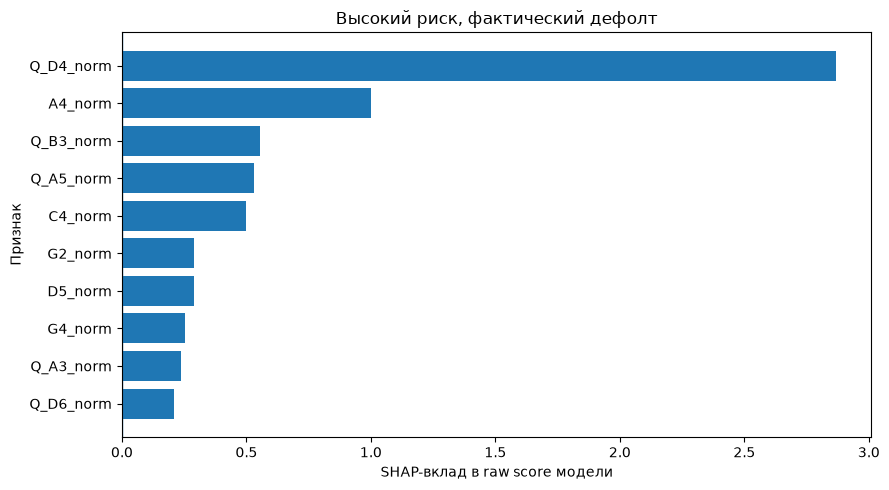


Низкий риск, без дефолта · target=0 · P(default)=0.0003


,Признак,Значение,SHAP-вклад
5,Q_A6_norm,93.8581,-1.5017
4,Q_A5_norm,43.7548,-1.1161
10,Q_C1_norm,67.9369,-1.0461
20,A4_norm,-19.8833,-0.5950
35,E1_norm,-26.9374,-0.3551
7,Q_B3_norm,18.8384,-0.2912
16,Q_D6_norm,-38.9530,+0.2762
42,G1_norm,-40.2537,+0.2583
45,G4_norm,-9.6960,-0.2086
3,Q_A4_norm,57.4046,-0.2068


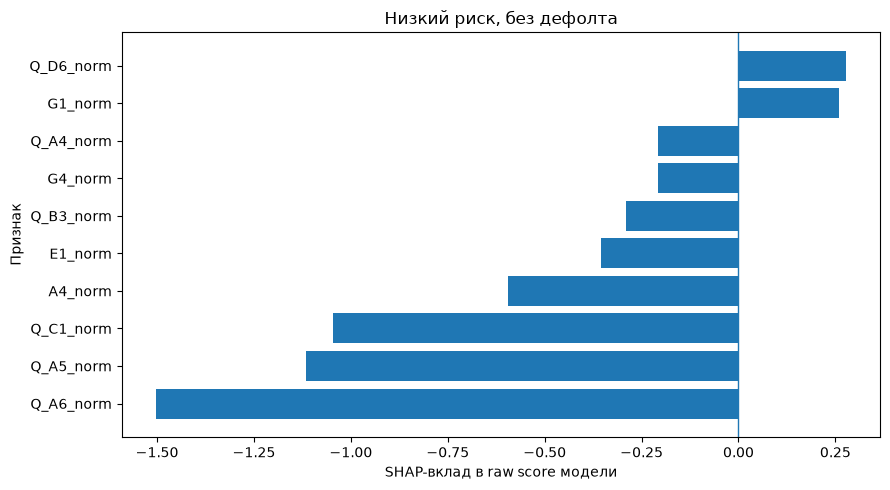


Пограничный прогноз · target=1 · P(default)=0.5000


,Признак,Значение,SHAP-вклад
42,G1_norm,-32.8921,+0.5635
43,G2_norm,-55.8823,+0.4639
16,Q_D6_norm,-38.9530,+0.4556
20,A4_norm,-23.6798,+0.2955
34,D5_norm,-1.0351,+0.2712
4,Q_A5_norm,24.7409,-0.2439
10,Q_C1_norm,-34.8407,+0.2163
14,Q_D4_norm,9.1750,-0.1824
7,Q_B3_norm,18.8384,-0.1526
23,B1_norm,-26.2029,+0.1477


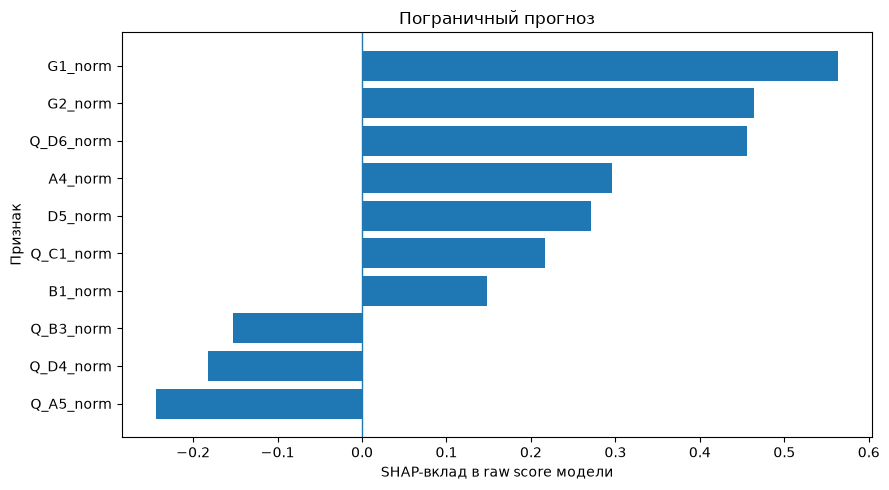

In [12]:
def выбрать_лучший_локальный_пример(
    кандидаты: list[dict[str, Any]],
    сценарий: str,
) -> dict[str, Any]:
    """Выбирает один пример заданного сценария среди трёх внешних фолдов."""
    подходящие = [x for x in кандидаты if x["Сценарий"] == сценарий]
    if not подходящие:
        raise RuntimeError(f"Нет локальных кандидатов для сценария: {сценарий}")

    if сценарий == "Высокий риск, фактический дефолт":
        return max(подходящие, key=lambda x: x["Вероятность дефолта"])

    if сценарий == "Низкий риск, без дефолта":
        return min(подходящие, key=lambda x: x["Вероятность дефолта"])

    return min(
        подходящие,
        key=lambda x: abs(x["Вероятность дефолта"] - 0.5),
    )


ЛОКАЛЬНЫЕ_ПРИМЕРЫ = [
    выбрать_лучший_локальный_пример(
        локальные_кандидаты,
        "Высокий риск, фактический дефолт",
    ),
    выбрать_лучший_локальный_пример(
        локальные_кандидаты,
        "Низкий риск, без дефолта",
    ),
    выбрать_лучший_локальный_пример(
        локальные_кандидаты,
        "Пограничный прогноз",
    ),
]

сводка_примеров = pd.DataFrame([
    {
        "Сценарий": пример["Сценарий"],
        "Фолд": пример["Фолд"],
        "Индекс рабочей выборки": пример["Индекс рабочей выборки"],
        "Target": пример["Target"],
        "Вероятность дефолта": пример["Вероятность дефолта"],
    }
    for пример in ЛОКАЛЬНЫЕ_ПРИМЕРЫ
])

display(сводка_примеров.style.format({
    "Вероятность дефолта": "{:.4f}",
}))

for пример in ЛОКАЛЬНЫЕ_ПРИМЕРЫ:
    строки = []
    for признак in ДОПУСТИМЫЕ_ПРИЗНАКИ:
        строки.append({
            "Признак": признак,
            "Значение": float(пример["Значения признаков"][признак]),
            "SHAP-вклад": float(пример["SHAP"][признак]),
            "|SHAP|": abs(float(пример["SHAP"][признак])),
        })

    локальная_таблица = (
        pd.DataFrame(строки)
        .sort_values("|SHAP|", ascending=False)
        .head(10)
    )

    print(
        f"\n{пример['Сценарий']} · "
        f"target={пример['Target']} · "
        f"P(default)={пример['Вероятность дефолта']:.4f}"
    )
    display(
        локальная_таблица[["Признак", "Значение", "SHAP-вклад"]]
        .style.format({
            "Значение": "{:.4f}",
            "SHAP-вклад": "{:+.4f}",
        })
    )

    plot_data = (
        локальная_таблица
        .sort_values("SHAP-вклад", ascending=True)
    )

    plt.figure(figsize=(9, 5))
    plt.barh(plot_data["Признак"], plot_data["SHAP-вклад"])
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("SHAP-вклад в raw score модели")
    plt.ylabel("Признак")
    plt.title(пример["Сценарий"])
    plt.tight_layout()
    plt.show()

# 7. Сохранение результатов и итоговый вывод

## Исследовательский вопрос

Достаточно ли метаданных сохранено, чтобы позже проверить, какой dataset, split, параметры, версии библиотек и методика объяснения дали этот результат?

Сырые INN и final test в артефакты Stage 2 не сохраняются.


In [13]:
def json_default(obj: Any) -> Any:
    """Преобразует numpy-объекты в JSON-совместимые типы."""
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Тип {type(obj).__name__} не сериализуется в JSON.")


версии = {
    пакет: importlib_metadata.version(пакет)
    for пакет in [
        "numpy",
        "pandas",
        "scikit-learn",
        "pyxlsb",
        "catboost",
        "xgboost",
        "lightgbm",
        "matplotlib",
        "shap",
    ]
}

ПУТЬ_CONSENSUS = ПАПКА_ОТЧЁТОВ / "stage2_explainability_consensus_V1.csv"
ПУТЬ_BY_MODEL = ПАПКА_ОТЧЁТОВ / "stage2_explainability_by_model_V1.csv"
ПУТЬ_JSON = ПАПКА_ОТЧЁТОВ / "stage2_explainability_results_V1.json"

ТАБЛИЦА_CONSENSUS.to_csv(
    ПУТЬ_CONSENSUS,
    index=False,
    encoding="utf-8-sig",
)

таблица_by_model = (
    ТАБЛИЦА_SHAP
    .merge(
        ТАБЛИЦА_PERM,
        on=["Модель", "Признак"],
        how="inner",
        validate="one_to_one",
    )
)

таблица_by_model.to_csv(
    ПУТЬ_BY_MODEL,
    index=False,
    encoding="utf-8-sig",
)

локальные_для_json = []

for пример in ЛОКАЛЬНЫЕ_ПРИМЕРЫ:
    топ = sorted(
        [
            {
                "признак": признак,
                "значение": float(пример["Значения признаков"][признак]),
                "shap": float(пример["SHAP"][признак]),
            }
            for признак in ДОПУСТИМЫЕ_ПРИЗНАКИ
        ],
        key=lambda x: abs(x["shap"]),
        reverse=True,
    )[:10]

    локальные_для_json.append({
        "сценарий": пример["Сценарий"],
        "фолд": пример["Фолд"],
        "индекс_рабочей_выборки": пример["Индекс рабочей выборки"],
        "target": пример["Target"],
        "вероятность_дефолта": пример["Вероятность дефолта"],
        "top10_shap": топ,
    })

результат_json = {
    "исследовательский_вопрос": (
        "Какие из 47 допустимых признаков стабильно формируют прогноз "
        "после полного исключения Q_B1_norm и Q_B2_norm?"
    ),
    "dataset": {
        "sha256": фактический_sha256,
        "строк": len(данные),
        "допустимых_признаков": len(ДОПУСТИМЫЕ_ПРИЗНАКИ),
        "исключённые_признаки": ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ,
    },
    "split": {
        "sha256_индексов_работа": SHA_ИНДЕКСОВ_РАБОТА,
        "sha256_индексов_test": SHA_ИНДЕКСОВ_TEST,
        "final_test_использован": False,
        "число_фолдов": ЧИСЛО_ФОЛДОВ,
        "seed": СЛУЧАЙНОЕ_ЗЕРНО,
    },
    "протокол": {
        "размер_shap_выборки_на_фолд": РАЗМЕР_SHAP_ВЫБОРКИ_НА_ФОЛД,
        "повторов_permutation": ПОВТОРОВ_PERMUTATION,
        "scoring_permutation": "roc_auc",
        "early_stopping_protocol": "inner_validation_then_refit_outer_train",
        "global_shap": "native_tree_shap_on_outer_validation_sample",
        "local_shap": "XGBoost outer-validation examples",
    },
    "воспроизведение_stage1_v2": ТАБЛИЦА_ВОСПРОИЗВЕДЕНИЯ.to_dict(
        orient="records"
    ),
    "consensus_top20": ТАБЛИЦА_CONSENSUS.head(20).to_dict(
        orient="records"
    ),
    "historical_overlap_top15": {
        "совпало": len(пересечение),
        "доля": ДОЛЯ_ПЕРЕСЕЧЕНИЯ,
        "признаки": пересечение,
        "ограничение": (
            "Historical importance относится к другому протоколу "
            "и удалению Q_B1_norm, а не обязательно обоих закрытых индексов."
        ),
    },
    "корреляция_shap_между_моделями": (
        КОРРЕЛЯЦИЯ_SHAP_МЕЖДУ_МОДЕЛЯМИ.to_dict()
    ),
    "корреляция_permutation_между_моделями": (
        КОРРЕЛЯЦИЯ_PERM_МЕЖДУ_МОДЕЛЯМИ.to_dict()
    ),
    "согласие_методов": ТАБЛИЦА_СОГЛАСИЯ_МЕТОДОВ.to_dict(
        orient="records"
    ),
    "стабильность_фолдов": ТАБЛИЦА_СТАБИЛЬНОСТИ_ФОЛДОВ.to_dict(
        orient="records"
    ),
    "локальные_примеры_xgboost": локальные_для_json,
    "параметры_моделей": ПАРАМЕТРЫ_МОДЕЛЕЙ,
    "версии_библиотек": версии,
    "общее_время_эксперимента_сек": ОБЩЕЕ_ВРЕМЯ_ЭКСПЕРИМЕНТА,
}

with ПУТЬ_JSON.open("w", encoding="utf-8") as файл:
    json.dump(
        результат_json,
        файл,
        ensure_ascii=False,
        indent=2,
        default=json_default,
    )

print("Сохранено:")
print("-", ПУТЬ_JSON)
print("-", ПУТЬ_CONSENSUS)
print("-", ПУТЬ_BY_MODEL)

Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage2_explainability_results_V1.json
- D:\Projects\komus-credit-risk\reports\generated\stage2_explainability_consensus_V1.csv
- D:\Projects\komus-credit-risk\reports\generated\stage2_explainability_by_model_V1.csv


In [14]:
top10 = ТАБЛИЦА_CONSENSUS.head(10)["Признак"].tolist()

минимальная_корр_shap = float(
    КОРРЕЛЯЦИЯ_SHAP_МЕЖДУ_МОДЕЛЯМИ.to_numpy()[
        np.triu_indices(len(МОДЕЛИ), k=1)
    ].min()
)

минимальная_корр_perm = float(
    КОРРЕЛЯЦИЯ_PERM_МЕЖДУ_МОДЕЛЯМИ.to_numpy()[
        np.triu_indices(len(МОДЕЛИ), k=1)
    ].min()
)

display(Markdown(f"""
# Итог Stage 2 V1

## ФАКТЫ

- Stage 1 V2 воспроизведён в пределах заранее установленного допуска по Gini.
- Final test не использован.
- Global SHAP и permutation importance рассчитаны на внешних validation-подвыборках.
- Consensus top-10: **{", ".join(top10)}**.
- Минимальная межмодельная корреляция рангов SHAP: **{минимальная_корр_shap:.3f}**.
- Минимальная межмодельная корреляция рангов permutation importance: **{минимальная_корр_perm:.3f}**.
- Пересечение consensus top-15 с historical top-15 заказчика: **{len(пересечение)}/15**.

## ИНТЕРПРЕТАЦИЯ

Признаки в верхней части consensus-рейтинга являются наиболее устойчивыми кандидатами на факторы, на которые опирается новый baseline без закрытых индексов.

Совпадение между моделями и между SHAP/permutation усиливает уверенность, что результат не является артефактом одной конкретной реализации бустинга.

## ОГРАНИЧЕНИЯ

- Важность не равна причинному влиянию.
- Коррелирующие признаки могут делить или перехватывать важность друг у друга.
- Explainability рассчитана на стратифицированной подвыборке validation-строк, а не на всех 289 614 рабочих строках.
- Historical comparison не является контролируемой репликацией: протокол заказчика отличался.
- Random split не доказывает temporal stability.
- Высокая важность после удаления `Q_B1_norm` / `Q_B2_norm` не доказывает, что признак содержит тот же скрытый сигнал.

## СЛЕДУЮЩИЙ ШАГ

Следующий исследовательский вопрос формулируется **после просмотра фактического consensus**: где именно остался информационный провал и какую одну прозрачную группу новых признаков имеет смысл проверить первой.
"""))


# Итог Stage 2 V1

## ФАКТЫ

- Stage 1 V2 воспроизведён в пределах заранее установленного допуска по Gini.
- Final test не использован.
- Global SHAP и permutation importance рассчитаны на внешних validation-подвыборках.
- Consensus top-10: **Q_D6_norm, Q_A5_norm, Q_B3_norm, Q_C1_norm, G1_norm, Q_D4_norm, D5_norm, A4_norm, C4_norm, Q_A4_norm**.
- Минимальная межмодельная корреляция рангов SHAP: **0.974**.
- Минимальная межмодельная корреляция рангов permutation importance: **0.899**.
- Пересечение consensus top-15 с historical top-15 заказчика: **13/15**.

## ИНТЕРПРЕТАЦИЯ

Признаки в верхней части consensus-рейтинга являются наиболее устойчивыми кандидатами на факторы, на которые опирается новый baseline без закрытых индексов.

Совпадение между моделями и между SHAP/permutation усиливает уверенность, что результат не является артефактом одной конкретной реализации бустинга.

## ОГРАНИЧЕНИЯ

- Важность не равна причинному влиянию.
- Коррелирующие признаки могут делить или перехватывать важность друг у друга.
- Explainability рассчитана на стратифицированной подвыборке validation-строк, а не на всех 289 614 рабочих строках.
- Historical comparison не является контролируемой репликацией: протокол заказчика отличался.
- Random split не доказывает temporal stability.
- Высокая важность после удаления `Q_B1_norm` / `Q_B2_norm` не доказывает, что признак содержит тот же скрытый сигнал.

## СЛЕДУЮЩИЙ ШАГ

Следующий исследовательский вопрос формулируется **после просмотра фактического consensus**: где именно остался информационный провал и какую одну прозрачную группу новых признаков имеет смысл проверить первой.
